# Case Study: Restarting Profit Growth at a Stalled Online Retailer

*A practice case built on the [E-Commerce Sales & Customer Analytics](https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics) dataset. Companion to [`Price_Sensitivity_Analysis.ipynb`](Price_Sensitivity_Analysis.ipynb).*

**How to use this notebook:** each step has a **🧠 Your turn** prompt. Try to answer it on paper (out loud, timed, as in an interview) before opening the model answer. The code cells do the analysis a case team would ask for.

| Step | Case skill practiced |
|---|---|
| 1. The prompt | Clarifying questions, restating the objective |
| 2. Structure | Building a MECE profit tree |
| 3. Diagnose | Reading a KPI table and spotting what moved |
| 4. Deep dives | Hypothesis-driven analysis and sizing |
| 5. Data sanity checks | Catching messy and misleading data |
| 6. Prioritize | Impact vs. effort, avoiding double-counting |
| 7. Recommend | Answer-first synthesis, roadmap, risks |

## 1. The prompt

> **ShopCo** is a multi-category online retailer selling across 15 categories (electronics to groceries) in 7 countries through its website, app, marketplaces and social channels. Revenue has been stuck at about **\$34M a year for five years**. The new CEO has promised the board **20% higher merchandise profit within three years** and asks you: *Where is the profit going to come from, and what should we do first?*

> **🧠 Your turn:** What clarifying questions would you ask before structuring the problem?

<details><summary><b>Show a model answer</b></summary>

Good clarifying questions narrow the objective, the scope and the constraints:

- **Objective:** Is the goal profit dollars or margin? Is "merchandise profit" revenue after discounts minus product cost? *(Assume yes. It excludes shipping, fulfilment and marketing.)*
- **Baseline:** Profit on what base: last year (2025)? *(Yes: about \$12.8M, so the target is about +\$2.6M a year by 2028.)*
- **Scope:** All markets and categories? Can we change prices, or only promotions? *(Everything is in scope. List prices are set by category managers, so discounts are the main pricing lever.)*
- **Constraints:** Any investment budget, or areas the CEO considers off-limits? *(Modest budget, no acquisitions.)*
- **Context:** Why flat now: market slowdown, competition, internal? *(Unknown. That's for you to find.)*

</details>

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
if not (DATA_DIR / "order_items.csv").exists():
    from download_data import download
    download()

pd.set_option("display.float_format", "{:,.2f}".format)
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10, "figure.dpi": 110,
})

items = pd.read_csv(DATA_DIR / "order_items.csv")
orders = pd.read_csv(DATA_DIR / "ecommerce_sales_customer_analytics_150k.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA_DIR / "customer_master.csv")

items["revenue"] = items.gross_sales - items.discount_amount
items["merch_profit"] = items.revenue - items.product_cost
order_totals = items.groupby("order_id")[["gross_sales", "discount_amount", "revenue", "merch_profit"]].sum()
orders = orders.join(order_totals.add_prefix("o_"), on="order_id")
orders["year"] = orders.order_date.dt.year
orders["discount_rate"] = orders.o_discount_amount / orders.o_gross_sales
YEARS = orders.year.nunique()
print(f"{len(orders):,} orders, {len(items):,} order lines, {orders.customer_id.nunique():,} customers, {YEARS} years")

138,116 orders, 397,569 order lines, 24,911 customers, 5 years


## 2. Structure the problem

> **🧠 Your turn:** Draw a profit tree for ShopCo. Which branches can this dataset inform?

<details><summary><b>Show a model answer</b></summary>

A MECE merchandise-profit tree:

```
Merchandise profit
├── Revenue (after discounts)
│   ├── Active customers ── new customers acquired
│   │                    └─ existing customers retained
│   ├── Orders per active customer
│   ├── Average order value ── units per order × list price
│   └── Discounts given (price realization)
├── Product cost (COGS)
└── Leakage ── cancelled orders (payment failures)
             └─ returned orders
```

The dataset covers customers (first order date, segment, acquisition cost), orders (status, channel, discounts) and lines (price, cost). It **can't** inform supplier costs or the competitive market, so state those as out of scope / next steps.

**Hypotheses to test** (state them before looking at the data):
1. **Customer growth has stalled.** Too few new customers are replacing those who leave.
2. **Discounts are leaking margin.** Many discounts don't change behavior.
3. **Revenue is lost to failed payments and returns.**
4. **Some channels, markets or segments are much less profitable than others.**

</details>

## 3. Diagnose: what has (and hasn't) moved?

In [2]:
first_order_year = orders.groupby("customer_id").order_date.min().dt.year
kpis = orders.groupby("year").agg(
    revenue_m=("o_revenue", lambda s: s.sum() / 1e6),
    merch_profit_m=("o_merch_profit", lambda s: s.sum() / 1e6),
    active_customers=("customer_id", "nunique"),
    orders=("order_id", "size"),
    avg_order_value=("o_revenue", "mean"),
    discount_rate=("discount_rate", "mean"),
    return_rate=("order_status", lambda s: (s == "Returned").mean()),
    cancel_rate=("order_status", lambda s: (s == "Cancelled").mean()),
)
kpis["orders_per_customer"] = kpis.orders / kpis.active_customers
kpis["margin"] = kpis.merch_profit_m / kpis.revenue_m
kpis["new_customers"] = first_order_year.value_counts().sort_index()
active = orders.groupby("year").customer_id.apply(set)
kpis["retained_from_prior_yr"] = [np.nan] + [len(active[y] & active[y - 1]) / len(active[y - 1]) for y in kpis.index[1:]]
kpis.style.format({
    "revenue_m": "${:.1f}M", "merch_profit_m": "${:.2f}M", "active_customers": "{:,}", "orders": "{:,}",
    "avg_order_value": "${:,.0f}", "discount_rate": "{:.1%}", "return_rate": "{:.1%}", "cancel_rate": "{:.1%}",
    "orders_per_customer": "{:.2f}", "margin": "{:.1%}", "new_customers": "{:,}", "retained_from_prior_yr": "{:.0%}",
}, na_rep="–")

,revenue_m,merch_profit_m,active_customers,orders,avg_order_value,discount_rate,return_rate,cancel_rate,orders_per_customer,margin,new_customers,retained_from_prior_yr
year,,,,,,,,,,,,
2021,$34.4M,$12.94M,"16,635","27,554","$1,249",15.2%,6.6%,5.8%,1.66,37.6%,"16,635",–
2022,$34.2M,$12.85M,"16,793","27,564","$1,239",15.3%,6.6%,6.1%,1.64,37.6%,"5,631",67%
2023,$34.1M,$12.83M,"16,767","27,632","$1,234",15.2%,6.8%,6.2%,1.65,37.6%,"1,858",67%
2024,$34.2M,$12.94M,"16,818","27,768","$1,231",15.1%,7.0%,6.3%,1.65,37.8%,583,67%
2025,$33.8M,$12.79M,"16,717","27,598","$1,227",15.1%,7.1%,5.9%,1.65,37.8%,204,67%


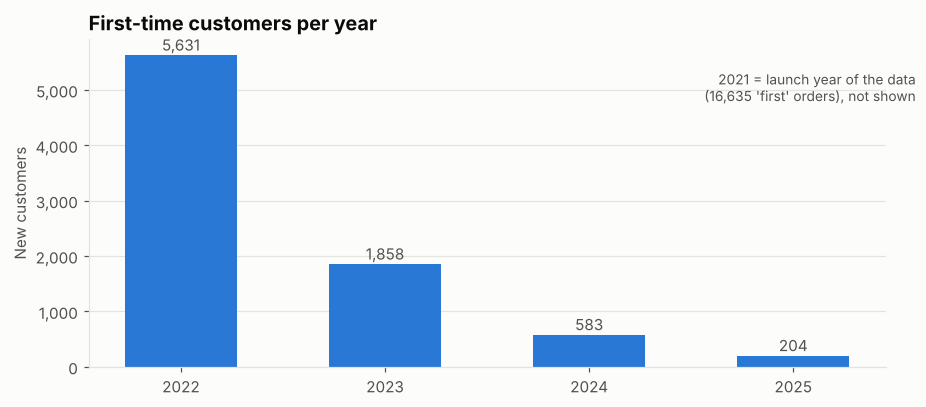

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
nc = kpis.new_customers.iloc[1:]
ax.bar(nc.index.astype(str), nc, color=BLUE, width=0.55)
for i, v in enumerate(nc):
    ax.text(i, v + 80, f"{v:,}", ha="center", color=INK_2)
ax.set(title="First-time customers per year", ylabel="New customers")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.text(3.6, 4800, "2021 = launch year of the data\n(16,635 'first' orders), not shown", ha="right", color=INK_2, fontsize=9)
plt.tight_layout(); plt.show()

> **🧠 Your turn:** What jumps out from the KPI table? What would you tell the CEO after five minutes?

<details><summary><b>Show a model answer</b></summary>

- **Almost everything is flat:** revenue, profit, margin (37.6%), orders per customer (1.65) and discount rate (15%). Average order value is drifting down slightly (−1.8% since 2021), and returns are creeping up (6.6% → 7.1%).
- **The one dramatic change is acquisition.** First-time customers fell from 5,631 in 2022 to **204 in 2025 (−96%)**. 99% of today's customers first bought before 2023.
- **Retention is about 67% a year.** A third of last year's customers don't buy this year.

**Five-minute headline:** "The business isn't shrinking yet, but it's living off a customer base it stopped growing three years ago. Flat revenue is hiding a pipeline problem. The fastest profit levers are pricing and leakage; the durable one is restarting acquisition."

*(Data sense check: with 67% retention and almost no new customers, the active base should be shrinking about 30% a year, yet it's flat. In a real case you'd ask the client how that reconciles: reactivated lapsed customers? a definition change? See Section 5.)*

</details>

## 4. Deep dives

### 4a. Hypothesis 2: discounts are leaking margin
The companion notebook found that **discounts of 0–23% don't change how many units customers buy**, volume jumps at about 25% off, and anything past 30% adds no volume. Here we size the yearly profit at stake and look at who gets the discounts.

In [4]:
LOW_Q = items.loc[items.discount_percentage < .23, "quantity"].mean()
HIGH_Q = items.loc[items.discount_percentage >= .27, "quantity"].mean()
unit_cost = items.product_cost / items.quantity

def merch_profit_under(new_disc):
    # Lines keep their observed volume unless the new discount crosses the ~25% threshold
    old = items.discount_percentage
    qty = items.quantity.astype(float)
    qty = qty.where(~((old >= .27) & (new_disc < .23)), qty * LOW_Q / HIGH_Q)
    qty = qty.where(~((old < .23) & (new_disc >= .27)), qty * HIGH_Q / LOW_Q)
    return (qty * items.unit_price * (1 - new_disc) - qty * unit_cost).sum()

d = items.discount_percentage
base = merch_profit_under(d)
pricing = pd.Series({
    "A. Stop discounts under 23%": merch_profit_under(d.where(d >= .23, 0)) - base,
    "B. Cap discounts at 30%": merch_profit_under(d.clip(upper=.30)) - base,
    "A + B": merch_profit_under(d.where(d >= .23, 0).clip(upper=.30)) - base,
}) / YEARS / 1e6
pricing.to_frame("extra merch profit per year ($M)")

,extra merch profit per year ($M)
A. Stop discounts under 23%,2.79
B. Cap discounts at 30%,0.93
A + B,3.71


In [5]:
seg = orders.groupby("customer_segment").agg(
    orders=("order_id", "size"), discount_rate=("discount_rate", "mean"),
    orders_per_customer=("customer_order_count", "mean"), lifetime_value=("customer_lifetime_value", "mean"),
    rating=("customer_rating", "mean"), profit_per_order=("o_merch_profit", "mean"),
)
seg.style.format({"orders": "{:,}", "discount_rate": "{:.1%}", "orders_per_customer": "{:.2f}",
                  "lifetime_value": "${:,.0f}", "rating": "{:.2f}", "profit_per_order": "${:,.0f}"})

,orders,discount_rate,orders_per_customer,lifetime_value,rating,profit_per_order
customer_segment,,,,,,
Business,"13,777",13.9%,6.91,"$8,915",3.63,$481
Consumer,"75,636",13.8%,7.03,"$9,037",3.63,$481
Premium,"34,746",17.6%,6.95,"$8,878",3.73,$438
VIP,"13,957",17.7%,6.94,"$8,906",3.83,$438


> **🧠 Your turn:** What do you conclude about discounts, and what would you recommend?

<details><summary><b>Show a model answer</b></summary>

- **Discounts under 23% are pure giveaway.** Stopping them is worth about **\$2.8M a year** in this model; capping at 30% adds about **\$0.9M**. Together that's about **\$3.7M a year**, more than the whole \$2.6M target, from one lever.
- **Premium and VIP customers get deeper discounts (17.6% vs. 13.8%) but don't order more often or have higher lifetime value.** Their only gain is a slightly higher rating. Loyalty discounts aren't buying loyalty.

**Recommendation:** move from "a little off everything" to a few **threshold promotions (25–30% off) on selected items and dates**, and replace blanket Premium/VIP percentage-off with non-price perks (free express shipping, early access).

**Pressure-test it:** the model assumes customers who lose a 10% discount keep buying the same amount, because the data shows no volume response below 23%. In reality, some may churn or shop at competitors. So **don't count the full \$3.7M**; risk-adjust it (Section 6) and **A/B test before rolling out**.

</details>

### 4b. Hypothesis 3: profit lost to cancellations and returns

In [6]:
leak = orders[orders.order_status.isin(["Cancelled", "Returned", "Pending"])].groupby("order_status").agg(
    orders=("order_id", "size"), merch_profit_per_year_m=("o_merch_profit", lambda s: s.sum() / YEARS / 1e6))
display(leak.style.format({"orders": "{:,}", "merch_profit_per_year_m": "${:.2f}M"}))
display(pd.crosstab(orders.order_status, orders.payment_status))
print(orders[orders.order_status == "Returned"].return_reason.value_counts(normalize=True).round(3).to_string())

,orders,merch_profit_per_year_m
order_status,,
Cancelled,"8,398",$1.04M
Pending,"6,697",$0.59M
Returned,"9,462",$1.20M


payment_status,Failed,Paid,Pending,Refunded
order_status,,,,
Cancelled,8398,0,0,0
Completed,0,102253,11306,0
Pending,2031,1997,2669,0
Returned,0,0,0,9462


return_reason
Wrong Product             0.13
Other                     0.13
Changed Mind              0.13
Size Issue                0.12
Defective Product         0.12
Late Delivery             0.12
Product Not as Expected   0.12
Damaged Product           0.12


> **🧠 Your turn:** Where is the leakage, and what would you do about each part?

<details><summary><b>Show a model answer</b></summary>

- **Every cancelled order is a failed payment** (8,398 orders, all marked `Failed`). That's about **\$1.0M of merchandise profit lost a year**: customers who wanted to buy and couldn't pay. Fixes: automatic payment retries, a prompt to use a backup payment method, a saved wallet, recovery emails. Recovering **30%** is a common target → about **\$0.3M a year**.
- **Returns cost about \$1.2M a year in merchandise profit**, spread evenly across 8 reasons (wrong product, damaged, size, late delivery…). No single fix stands out. Start with the operational ones (wrong product, damaged, defective: about 37% of returns), which are fixable in the warehouse. Cutting returns 20% → about **\$0.25M a year**.
- **Pending orders that failed payment** (about 2,000) belong in the same payment-recovery workstream.

Total leakage lever: about **\$0.5M a year**. Smaller, but low-risk and fast.

</details>

### 4c. Hypothesis 1: customer growth has stalled

In [7]:
cust_profit = orders.groupby(["year", "customer_id"]).o_merch_profit.sum().groupby("year").mean()
cac = customers.customer_acquisition_cost.mean()
print(f"Merchandise profit per active customer per year: ${cust_profit.mean():,.0f}")
print(f"Average customer acquisition cost (CAC):        ${cac:,.0f}")
print(f"Year-1 merch profit / CAC:                       {cust_profit.mean() / cac:,.0f}x")

def added_profit(new_per_year, retention=0.67, years=3, profit_each=cust_profit.mean()):
    # Active customers added by year N when acquiring `new_per_year` customers a year at the given retention
    added = sum(new_per_year * retention**k for k in range(years))
    return added, added * profit_each / 1e6

for n in [500, 1000, 2000]:
    added, profit = added_profit(n)
    print(f"Acquire {n:>5,}/yr → +{added:,.0f} active customers by year 3 → +${profit:.1f}M merch profit/yr "
          f"(acquisition spend at today's CAC: ${n * cac / 1e3:,.0f}k/yr)")

Merchandise profit per active customer per year: $768
Average customer acquisition cost (CAC):        $42
Year-1 merch profit / CAC:                       18x
Acquire   500/yr → +1,059 active customers by year 3 → +$0.8M merch profit/yr (acquisition spend at today's CAC: $21k/yr)
Acquire 1,000/yr → +2,119 active customers by year 3 → +$1.6M merch profit/yr (acquisition spend at today's CAC: $42k/yr)
Acquire 2,000/yr → +4,238 active customers by year 3 → +$3.3M merch profit/yr (acquisition spend at today's CAC: $84k/yr)


> **🧠 Your turn:** How big is the acquisition opportunity, and how much should you trust that number?

<details><summary><b>Show a model answer</b></summary>

- An active customer generates about **\$770 of merchandise profit a year**, and the recorded CAC is about **\$42**. On paper, every new customer pays back in weeks. Underinvesting in acquisition is the strategic error behind the flat top line.
- Getting back to **1,000 new customers a year** (a sixth of the 2022 level) adds about **2,100 active customers by year 3**, worth about **\$1.6M a year** in merchandise profit.

**Why to be careful:**
- Merchandise profit leaves out shipping, fulfilment and service costs. Real contribution per customer might be half.
- The \$42 CAC is historical. Marginal CAC rises as you scale, since the cheapest customers were won first.
- New customers usually spend less than the loyal base and churn faster.

So present this as a **range (\$0.8–1.6M a year by year 3)** and propose **channel tests** to measure real marginal CAC. Note that in this data every marketing channel shows almost identical order value and profit (Section 5), so start with the cheapest channels (referral, email, organic search) rather than a costly brand campaign.

</details>

### 4d. Hypothesis 4: are some channels, markets or segments less profitable?

In [8]:
dims = ["sales_channel", "marketing_channel", "customer_country", "shipping_method", "payment_method"]
spread = []
for dim in dims:
    t = orders.groupby(dim).agg(profit_per_order=("o_merch_profit", "mean"), return_rate=("order_status", lambda s: (s == "Returned").mean()))
    spread.append({"dimension": dim, "groups": len(t),
                   "profit/order low": t.profit_per_order.min(), "profit/order high": t.profit_per_order.max(),
                   "return rate low": t.return_rate.min(), "return rate high": t.return_rate.max()})
pd.DataFrame(spread).set_index("dimension").style.format({
    "profit/order low": "${:,.0f}", "profit/order high": "${:,.0f}", "return rate low": "{:.1%}", "return rate high": "{:.1%}"})

,groups,profit/order low,profit/order high,return rate low,return rate high
dimension,,,,,
sales_channel,4,$464,$467,6.4%,6.9%
marketing_channel,10,$463,$472,6.6%,7.1%
customer_country,7,$463,$474,6.2%,7.3%
shipping_method,4,$464,$467,6.6%,6.9%
payment_method,7,$461,$471,6.5%,7.1%


In [9]:
dl = orders[orders.delivery_status.isin(["Early", "On Time", "Delayed"])]
dl.groupby("delivery_status").agg(orders=("order_id", "size"), share=("order_id", lambda s: len(s) / len(dl)),
                                  avg_rating=("customer_rating", "mean")).style.format(
    {"orders": "{:,}", "share": "{:.0%}", "avg_rating": "{:.2f}"})

,orders,share,avg_rating
delivery_status,,,
Delayed,"16,886",15%,3.22
Early,"9,757",9%,4.02
On Time,"86,916",77%,3.73


> **🧠 Your turn:** Hypothesis 4 came back negative. How do you handle that in front of a client?

<details><summary><b>Show a model answer</b></summary>

**Say it clearly and move on. A disproven hypothesis is a finding.** Profit per order varies by less than 3% across sales channels, marketing channels, countries, shipping methods and payment methods. Return rates sit in a 6–7% band everywhere. *"Channel and market mix isn't where the profit is. We shouldn't spend the next month there."*

One operational signal is worth flagging: **about 15% of delivered orders arrive late**, at every warehouse and with every shipping method, including Same Day. Late orders are rated **3.2 vs. 3.7** on time. Customers paying \$37 for same-day shipping get the same 15% late rate. That's a customer-experience risk for retention (which is currently about 67%), though this data can't show a direct revenue impact. Put it on the roadmap as a test, not a headline.

</details>

## 5. Data sanity checks

Real client data is messy. Part of the case skill is **noticing when a number is too good, too clean or doesn't add up**, before it reaches a slide.

In [10]:
returned = items.merge(orders[["order_id", "order_status"]], on="order_id")
print("Median discount on returned lines:", f"{returned.loc[returned.order_status == 'Returned', 'discount_percentage'].median():.0%}")
print("Median discount on completed lines:", f"{returned.loc[returned.order_status == 'Completed', 'discount_percentage'].median():.0%}")
reported = items.profit
print("Lines where the dataset's own 'profit' = revenue − cost:", f"{np.isclose(reported, items.merch_profit, atol=.05).mean():.1%}")
cat_lift = (items.assign(hi=items.discount_percentage >= .27)
            .merge(pd.read_csv(DATA_DIR / "product_catalog.csv")[["product_id", "product_category"]], on="product_id")
            .groupby(["product_category", "hi"]).quantity.mean().unstack())
print("Volume lift past the threshold, range across 15 categories:",
      f"{(cat_lift[True] / cat_lift[False] - 1).min():.0%} to {(cat_lift[True] / cat_lift[False] - 1).max():.0%}")

Median discount on returned lines: 0%
Median discount on completed lines: 14%
Lines where the dataset's own 'profit' = revenue − cost: 0.0%
Volume lift past the threshold, range across 15 categories: 71% to 74%


> **🧠 Your turn:** List the data issues you'd raise with the client, and how each changes your conclusions.

<details><summary><b>Show a model answer</b></summary>

1. **Returned orders show a 0% discount.** Refunds most likely wipe the discount field. So the pattern "deeper discounts → far fewer returns" (Section 7 of the companion notebook) is probably **an artifact, not an insight**. Don't present it.
2. **The dataset's own `profit` column doesn't reconcile** with revenue minus product cost for any line. We built our own definition and labelled it everywhere. *Always say which profit you're using.*
3. **The active customer base is flat** even though acquisition fell 96% and retention is 67%. Those can't all be true without heavy reactivation. Ask the client how "active" and "new" are defined.
4. **Customer response is identical across all 15 categories, 4 segments and 5 years** (volume lift 71–74% everywhere). Real shoppers aren't that uniform, so treat the discount model as directional and validate it with an A/B test.

**Case lesson:** state the caveat *alongside* the number (a range, a confidence level, the test that would confirm it) rather than dropping the number or hiding the caveat.

</details>

## 6. Prioritize

In [11]:
cancel_profit = leak.loc["Cancelled", "merch_profit_per_year_m"]
return_profit = leak.loc["Returned", "merch_profit_per_year_m"]
levers = pd.DataFrame([
    ["Discount redesign (stop <23%, cap at 30%)", pricing["A + B"], 0.5, "3–6 months", "Medium: customer reaction to losing small discounts"],
    ["Payment-failure recovery (30% recovered)", cancel_profit * 0.30, 0.8, "1–3 months", "Low"],
    ["Return reduction (−20%)", return_profit * 0.20, 0.6, "6–12 months", "Low–medium: operational change"],
    ["Restart acquisition (1,000 new/yr)", added_profit(1000)[1], 0.5, "12–36 months", "Medium: real CAC and new-customer value unknown"],
], columns=["lever", "full_potential_m", "confidence", "time_to_impact", "main_risk"]).set_index("lever")
levers["risk_adjusted_m"] = levers.full_potential_m * levers.confidence
target = kpis.merch_profit_m.iloc[-1] * 0.20
display(levers.style.format({"full_potential_m": "${:.2f}M", "confidence": "{:.0%}", "risk_adjusted_m": "${:.2f}M"}))
print(f"Target: +${target:.2f}M/yr | Risk-adjusted total: +${levers.risk_adjusted_m.sum():.2f}M/yr "
      f"({levers.risk_adjusted_m.sum() / target:.0%} of target)")

,full_potential_m,confidence,time_to_impact,main_risk,risk_adjusted_m
lever,,,,,
"Discount redesign (stop <23%, cap at 30%)",$3.71M,50%,3–6 months,Medium: customer reaction to losing small discounts,$1.86M
Payment-failure recovery (30% recovered),$0.31M,80%,1–3 months,Low,$0.25M
Return reduction (−20%),$0.24M,60%,6–12 months,Low–medium: operational change,$0.14M
"Restart acquisition (1,000 new/yr)",$1.63M,50%,12–36 months,Medium: real CAC and new-customer value unknown,$0.81M


Target: +$2.56M/yr | Risk-adjusted total: +$3.06M/yr (120% of target)


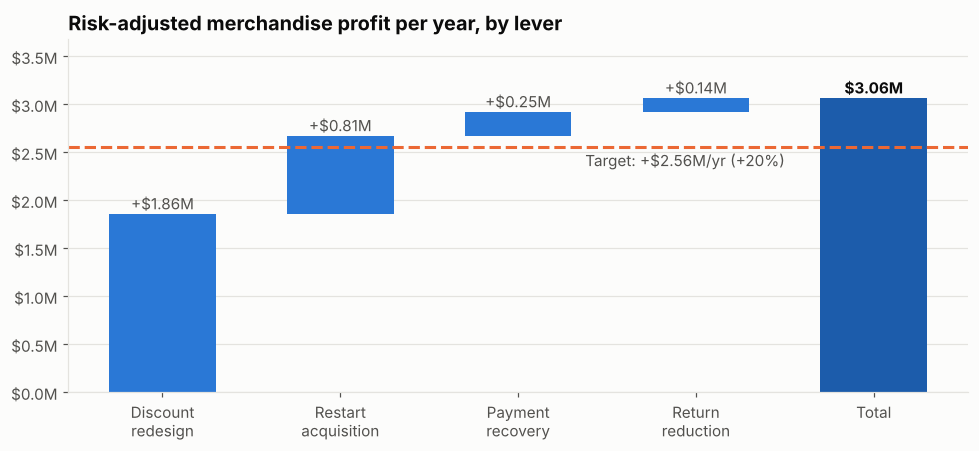

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ordered = levers.risk_adjusted_m.sort_values(ascending=False)
short = {"Discount redesign (stop <23%, cap at 30%)": "Discount\nredesign", "Restart acquisition (1,000 new/yr)": "Restart\nacquisition",
         "Payment-failure recovery (30% recovered)": "Payment\nrecovery", "Return reduction (−20%)": "Return\nreduction"}
bottom = 0
for i, (name, v) in enumerate(ordered.items()):
    ax.bar(i, v, bottom=bottom, color=BLUE, width=0.6)
    ax.text(i, bottom + v + 0.05, f"+${v:.2f}M", ha="center", color=INK_2)
    bottom += v
ax.bar(len(ordered), bottom, color="#1c5cab", width=0.6)
ax.text(len(ordered), bottom + 0.05, f"${bottom:.2f}M", ha="center", color=INK, fontweight="bold")
ax.axhline(target, color=ORANGE, lw=2, ls="--")
ax.text(3.5, target - 0.2, f"Target: +${target:.2f}M/yr (+20%)", color=INK_2, ha="right")
ax.set_xticks(range(len(ordered) + 1), [short[n] for n in ordered.index] + ["Total"])
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:.1f}M"))
ax.set(title="Risk-adjusted merchandise profit per year, by lever", ylim=(0, bottom * 1.2))
plt.tight_layout(); plt.show()

> **🧠 Your turn:** Which lever goes first, and why not just add up the full potential?

<details><summary><b>Show a model answer</b></summary>

- **Don't add up full potential.** Each lever has a different chance of delivering. Risk-adjusting turns about \$5.9M of paper upside into about **\$3.1M**, which clears the \$2.6M target with about 20% buffer. Also check for **double-counting**: the discount redesign and a separate "cut VIP discounts" lever would overlap, so we folded VIP discounts into the redesign.
- **Sequence by speed and risk:**
  1. **Payment recovery first.** Small, but fast, low-risk and good for credibility.
  2. **Discount redesign as an A/B test now.** It's the biggest lever, and pricing moves faster than anything else.
  3. **Start acquisition tests now** even though they pay off last. This is the only lever that fixes the underlying problem.
  4. **Returns** as an ongoing operations programme.

</details>

## 7. Recommendation

> **🧠 Final drill:** give the CEO your recommendation in 60 seconds, answer first. Then compare with the version below.

<details><summary><b>Show a model answer (60-second version)</b></summary>

**"ShopCo can hit +20% merchandise profit in three years, but only if it fixes pricing now and restarts customer growth at the same time.**

**First,** about \$2.8M a year of small discounts (under 23%) go to customers who'd buy the same amount anyway. Replacing them with fewer, deeper threshold promotions is worth \$1.9–3.7M a year. We'll A/B test it this quarter.

**Second,** every cancelled order is a failed payment. Payment retries and backup payment methods recover about \$0.3M a year within three months.

**Third, and most important for the long run,** first-time customers fell 96% since 2022. We're living off an aging base. Each new customer earns many times their acquisition cost, so we'll start low-cost acquisition tests now to rebuild the pipeline, worth about \$1M a year by year three.

Risk-adjusted, these deliver about \$3.1M a year against a \$2.6M target. The first decision we need from you is approval to run the pricing test."**

</details>

### Roadmap

| Timing | Action | Owner |
|---|---|---|
| **0–3 months** | Payment retries, backup payment prompt, failed-order recovery emails | Product / Payments |
| | A/B test: no discounts under 23% vs. control, in 3 categories | Pricing |
| | Pilot referral and email reactivation offers; measure real marginal CAC | Marketing |
| **3–12 months** | Roll out threshold promotion calendar (25–30% off, selected items and dates) | Pricing / Merchandising |
| | Replace VIP percentage-off with non-price perks (free express, early access) | CRM |
| | Warehouse quality checks on wrong / damaged / defective items (37% of returns) | Operations |
| **12–36 months** | Scale the acquisition channels that pass the CAC test | Marketing |
| | Fix the 15% late-delivery rate; test its effect on retention | Operations |

### Risks and how to manage them
- **Customers react badly to losing small discounts** → test first, keep a control group, watch retention as well as volume.
- **Real acquisition costs are higher than \$42** → scale only channels that pass a payback threshold (e.g. 12-month payback on contribution, not merchandise profit).
- **Data quality** (Section 5) → validate the definitions of "active", "new" and returns with the client before committing.

### What we'd ask the client for next
Shipping and fulfilment costs (to move from merchandise profit to true contribution), marketing spend by channel, competitor pricing, and the raw refund records.